In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import scanpy as sc
import anndata as ad
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# Input/Output paths
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

In [2]:
# Load data
# Gene expression data
GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_scvi_model_latent_20_20000_2025-10-09.h5ad"

print(f"Loading scVI data from {GE_ANNDATA_scVI_PATH}")
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)

Loading scVI data from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/scVI/ge_adata_with_scvi_model_latent_20_20000_2025-10-09.h5ad


In [3]:
# Splicing data 
SPLICE_ANNDATA_PATH = f"{BASE_DIR}/MODEL_INPUT/102025/aligned_splicing_data_20251003_152725.h5ad"
print(f"Loading splicing raw input data from {SPLICE_ANNDATA_PATH}")
splice_adata = ad.read_h5ad(SPLICE_ANNDATA_PATH)

Loading splicing raw input data from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/102025/aligned_splicing_data_20251003_152725.h5ad


In [4]:
# Get lists of marker gene and plot the normalized expression values 
ge_adata, splice_adata

(AnnData object with n_obs × n_vars = 142315 × 10572
     obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
     var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'gene_biotype', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'RBP_gene', 'Aging_gene', 'is_hvg', 'is_rbp', 'is_aging'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'broad_cell_type_colors', 'gene_selection', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_params', 'neighbors', 'scvi_linear', 'umap'
     obsm: 'X_li

In [5]:
# Load the aging gene datasets
aging_genes_mouse = "/gpfs/commons/groups/knowles_lab/Karin/HAGR/GenAge/model/genage_models.csv"
aging = pd.read_csv(aging_genes_mouse)
aging = aging[aging["organism"] == "Mus musculus"]

In [6]:
aging

,GenAge ID,symbol,name,organism,entrez gene id,avg lifespan change (max obsv),lifespan effect,longevity influence
5,6,Adcy5,adenylate cyclase 5,Mus musculus,224129.0,30.0,Increase,Anti-Longevity
12,13,Arhgap1,Rho GTPase activating protein 1,Mus musculus,228359.0,NaN,Decrease,Pro-Longevity
14,15,Arntl,aryl hydrocarbon receptor nuclear translocator...,Mus musculus,11865.0,NaN,Decrease,Pro-Longevity
23,24,Atm,Ataxia telangiectasia mutated homolog (human),Mus musculus,11920.0,NaN,Decrease,Pro-Longevity
29,30,Atr,Ataxia telangiectasia and Rad3 related,Mus musculus,245000.0,NaN,Decrease,Pro-Longevity
...,...,...,...,...,...,...,...,...
2136,2162,Per2,period circadian clock 2,Mus musculus,18627.0,NaN,Increase,Anti-Longevity
2137,2163,SOD3,superoxide dismutase 3,Mus musculus,6649.0,NaN,Decrease,Pro-Longevity
2145,2171,Mir17,microRNA 17,Mus musculus,723905.0,16.0,Increase,Pro-Longevity
2147,2173,Mir29a,microRNA 29a,Mus musculus,387222.0,NaN,NaN,Unannotated


In [7]:
# Remove old columns from ge_adata.var
ge_adata.var = ge_adata.var.drop(columns=['Aging_gene', 'is_aging'], errors='ignore')

In [13]:
# Prepare the aging dataframe with uppercase symbols for matching
aging['symbol_upper'] = aging['symbol'].str.upper()

# Create mapping dictionaries
name_map = aging.set_index('symbol_upper')['name'].to_dict()
lifespan_effect_map = aging.set_index('symbol_upper')['lifespan effect'].to_dict()
longevity_influence_map = aging.set_index('symbol_upper')['longevity influence'].to_dict()

# Create uppercase gene names for mapping
ge_adata.var['gene_name_upper'] = ge_adata.var['gene_name'].str.upper()

# Create the aging_gene boolean column (True if gene is in the aging list)
ge_adata.var['aging_gene'] = ge_adata.var['gene_name_upper'].isin(aging['symbol_upper'])

# Map the other columns
ge_adata.var['aging_gene_name'] = ge_adata.var['gene_name_upper'].map(name_map)
ge_adata.var['aging_lifespan_effect'] = ge_adata.var['gene_name_upper'].map(lifespan_effect_map)
ge_adata.var['aging_longevity_influence'] = ge_adata.var['gene_name_upper'].map(longevity_influence_map)

# Check results
print(f"Total aging genes mapped: {ge_adata.var['aging_gene'].sum()}")
print(f"Total genes in ge_adata: {len(ge_adata.var)}")
print(f"Percentage of aging genes: {ge_adata.var['aging_gene'].sum() / len(ge_adata.var) * 100:.2f}%")
print(f"\nSample of mapped aging genes:")
print(ge_adata.var[ge_adata.var['aging_gene']][['gene_name', 'aging_gene_name', 'aging_lifespan_effect', 'aging_longevity_influence']].head(10))

Total aging genes mapped: 97
Total genes in ge_adata: 10572
Percentage of aging genes: 0.92%

Sample of mapped aging genes:
     gene_name                                    aging_gene_name  \
6843     NCOR2                    nuclear receptor co-repressor 2   
7240     NUDT1  nudix (nucleoside diphosphate linked moiety X)...   
7711      PER2                           period circadian clock 2   
5073     IKBKB                    inhibitor of kappaB kinase beta   
4964     HTRA2                            HtrA serine peptidase 2   
495       AKT1                     thymoma viral proto-oncogene 1   
6672       MYC                          myelocytomatosis oncogene   
4034       FXN                                           frataxin   
4486      GPX4                           Glutathione peroxidase 4   
386     ADRA1A                      adrenergic receptor, alpha 1a   

     aging_lifespan_effect aging_longevity_influence  
6843              Decrease             Pro-Longevity  
7240  

In [14]:
# Transfer labels to splice_adata
gene_labels = ge_adata.var[['gene_name', 'gene_id', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influence']].drop_duplicates(subset='gene_id').set_index('gene_id')

# Map gene_name using gene_id as the key
splice_adata.var['gene_name'] = splice_adata.var['gene_id'].map(gene_labels['gene_name'])

# Map aging_gene as boolean
splice_adata.var['aging_gene'] = splice_adata.var['gene_id'].map(gene_labels['aging_gene']).fillna(False).astype(bool)

# Map aging_lifespan_effect and aging_longevity_influence (keep as strings, not boolean)
splice_adata.var['aging_lifespan_effect'] = splice_adata.var['gene_id'].map(gene_labels['aging_lifespan_effect'])
splice_adata.var['aging_longevity_influence'] = splice_adata.var['gene_id'].map(gene_labels['aging_longevity_influence'])

print(f"Splice Data: {splice_adata.var['aging_gene'].sum()} junctions from aging genes")

Splice Data: 936 junctions from aging genes


In [15]:
splice_adata.var.iloc[1]

junction_id                   chr10_100016155_100051845_+
event_id                     ENSMUSG00000019966.18_atse_1
splice_motif                                        GT-AG
annotation_status                                    both
gene_name                                            KITL
gene_id                             ENSMUSG00000019966.18
num_junctions                                           2
position_off_5_prime                                  0.0
position_off_3_prime                                  1.0
CountJuncs                                           5002
junction_id_index                                       1
n_cells_detected                                      795
confidence                                           high
aging_gene                                          False
aging_lifespan_effect                                 NaN
aging_longevity_influence                             NaN
Name: 1, dtype: object

In [16]:
splice_adata.obs[["medium_cell_type", "broad_cell_type"]].value_counts()

medium_cell_type              broad_cell_type     
Cortical excitatory neuron    Neuron                  30868
Inhibitory neuron             Neuron                  17259
Microglia                     Glial cell              12042
B cell                        Immune cell              8620
Skin epithelial cell          Epithelial cell          7347
Endothelial cell              Vascular cell            7044
Mesenchymal stem cell         Stem cell                4755
Fibroblast                    Stromal cell             4600
Hippocampal neuron            Neuron                   4476
T cell                        Immune cell              3571
Intestinal epithelial cell    Epithelial cell          3016
T cell precursor              Immune cell              3002
Granulocyte                   Immune cell              2860
Hematopoietic stem cell       Stem cell                2748
Other immune cell             Immune cell              2562
Skeletal muscle cell          Muscle cell        

In [17]:
ge_adata.var_names = ge_adata.var["gene_name"]

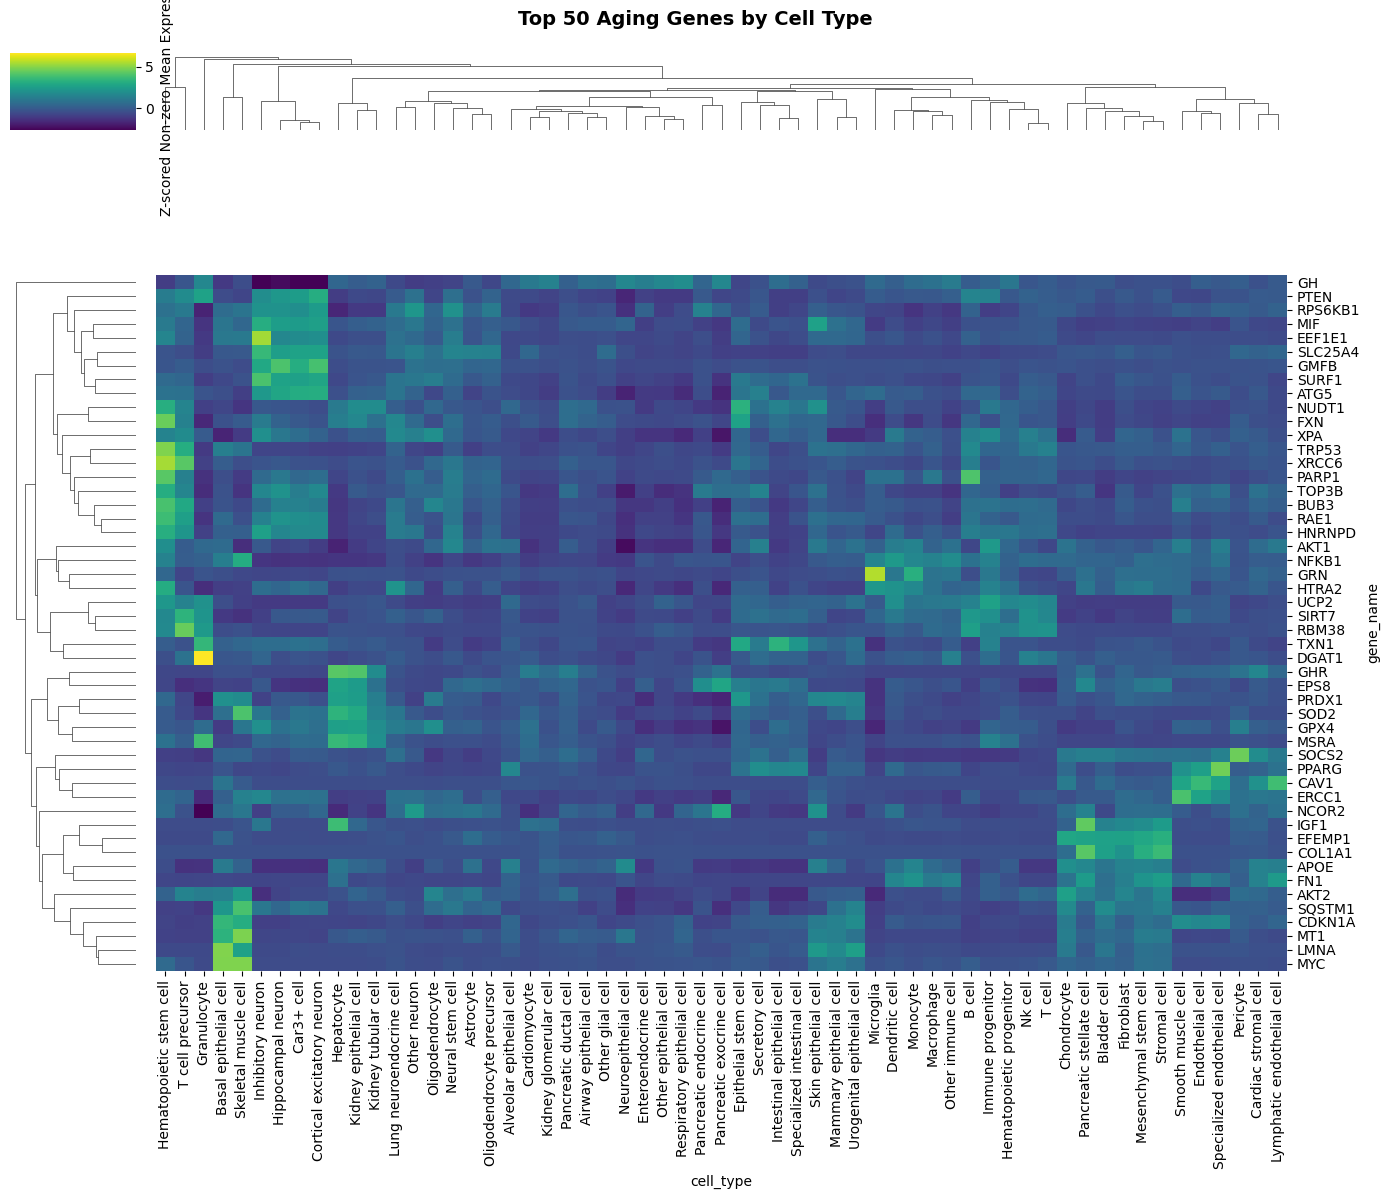


Analyzed 50 aging genes across 59 cell types
Total aging genes available: 97


In [18]:
# Select aging genes
aging_mask = ge_adata.var['aging_gene']
gene_names = ge_adata.var_names[aging_mask]

# Get normalized expression
normalized_expr_full = ge_adata.obsm['X_normalized_scVI_linear']
normalized_expr = normalized_expr_full.iloc[:, aging_mask.values]
normalized_expr.columns = gene_names

# Function to calculate non-zero mean
def nonzero_mean(x):
    nonzero = x[x > 0]
    return nonzero.mean() if len(nonzero) > 0 else 0

# Calculate non-zero mean by cell type
temp_df = normalized_expr.copy()
temp_df['cell_type'] = splice_adata.obs['medium_cell_type'].values
nonzero_mean_df = temp_df.groupby('cell_type').apply(
    lambda x: x.drop('cell_type', axis=1).apply(nonzero_mean)
).T

# Calculate mean expression across all cell types and get top 50
overall_mean_expr = nonzero_mean_df.mean(axis=1).sort_values(ascending=False)
top_50_genes = overall_mean_expr.head(50).index.tolist()

# Filter to top 50
nonzero_mean_df_filtered = nonzero_mean_df.loc[top_50_genes]

# Create the clustermap
g = sns.clustermap(
    nonzero_mean_df_filtered,
    cmap='viridis',
    z_score=0,
    figsize=(14, 12),
    cbar_kws={'label': 'Z-scored Non-zero Mean Expression'},
    yticklabels=True,
    xticklabels=True,
    dendrogram_ratio=0.1
)

plt.suptitle('Top 50 Aging Genes by Cell Type', 
             y=0.995, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nAnalyzed {len(top_50_genes)} aging genes across {nonzero_mean_df_filtered.shape[1]} cell types")
print(f"Total aging genes available: {aging_mask.sum()}")

In [19]:
splice_adata[splice_adata.obs["tissue"] == "Heart"].obs["medium_cell_type"].value_counts()

medium_cell_type
Fibroblast              3011
Endothelial cell        2275
Monocyte                 978
Cardiac stromal cell     579
Cardiomyocyte            436
B cell                   259
T cell                   166
Smooth muscle cell        92
Macrophage                60
Name: count, dtype: int64

In [20]:
# assert that splice_adata.obs and ge_adata.obs are the same 
# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values) 

In [21]:
# Save the updated distribution
combined_counts = splice_adata.obs[['tissue', 'cell_ontology_class']].value_counts()
combined_counts.to_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/GeneExpression/cell_type_distribution_medium.csv")
print("\nSaved detailed distribution to: cell_type_distribution_medium.csv")


Saved detailed distribution to: cell_type_distribution_medium.csv


In [22]:
combined_counts = splice_adata.obs[['tissue', 'cell_ontology_class', 'broad_cell_type', 'medium_cell_type']].value_counts()
combined_counts.to_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/GeneExpression/cell_type_distribution_medium.csv")
print("\nSaved detailed distribution to: cell_type_distribution_medium.csv")


Saved detailed distribution to: cell_type_distribution_medium.csv


In [23]:
# Convert to string temporarily
splice_adata.obs['medium_cell_type'] = splice_adata.obs['medium_cell_type'].astype(str)
splice_adata.obs['broad_cell_type'] = splice_adata.obs['broad_cell_type'].astype(str)

# Fix Car3+ cells
car3_mask = splice_adata.obs['cell_ontology_class'].str.contains('Car3', na=False)
splice_adata.obs.loc[car3_mask, 'broad_cell_type'] = 'Glial cell'
splice_adata.obs.loc[car3_mask, 'medium_cell_type'] = 'Car3+ astrocyte'

# Fix bladder redundancy
bladder_mask = splice_adata.obs['medium_cell_type'] == 'Bladder cell'
splice_adata.obs.loc[bladder_mask, 'medium_cell_type'] = 'Bladder epithelial cell'

# Convert back to categorical (optional, for memory efficiency)
splice_adata.obs['medium_cell_type'] = splice_adata.obs['medium_cell_type'].astype('category')
splice_adata.obs['broad_cell_type'] = splice_adata.obs['broad_cell_type'].astype('category')

print(f"Fixed {car3_mask.sum()} Car3+ cells")
print(f"Fixed {bladder_mask.sum()} Bladder cells")

Fixed 895 Car3+ cells
Fixed 521 Bladder cells


In [24]:
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
ge_adata.obs_names

Index(['A10_B000120', 'A10_B000126', 'A10_B000127', 'A10_B000166',
       'A10_B000169', 'A10_B000170', 'A10_B000176', 'A10_B000229',
       'A10_B000232', 'A10_B000246',
       ...
       'US-1250275_E2_S77', 'US-1250275_E2_S78', 'US-1250275_E2_S82',
       'US-1250275_E2_S83', 'US-1250275_E2_S85', 'US-1250275_E2_S86',
       'US-1250275_E2_S87', 'US-1250275_E2_S88', 'US-1250275_E2_S89',
       'US-1250275_E2_S90'],
      dtype='object', name='cell_id', length=142315)

In [25]:
ge_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]
ge_adata.obs["medium_cell_type"] = splice_adata.obs["medium_cell_type"]

In [26]:
# MOUSE CELL TYPE MARKERS - Aligned to YOUR cell type categories with UPPERCASE gene names
MOUSE_CELL_TYPE_MARKERS = {
    'Neuron': {
        'excitatory': ['SLC17A7', 'CAMK2A', 'SATB2', 'TBR1', 'BCL11B', 'FOXP2', 'SLC17A6', 'GRIN2A', 'GRIA1', 'GRIN1', 'DLG4', 'SYN1', 'SNAP25'],
        'inhibitory_general': ['GAD1', 'GAD2', 'SLC32A1', 'DLX1', 'DLX2', 'DLX5', 'SLC6A1', 'ADARB2', 'RELN'],
        'pvalb': ['PVALB', 'ERBB4', 'KCNC1', 'LHX6'],
        'sst': ['SST', 'CORT', 'NPY', 'NOS1'],
        'vip': ['VIP', 'CCK', 'CALB2', 'CRH'],
        'lamp5': ['LAMP5', 'PDYN', 'PAX6', 'EGR3'],
        'layer_specific': ['CUX2', 'RORB', 'FEZF2', 'FOXP2', 'TLE4']
    },
    
    'Glial cell': {
        'oligodendrocyte': ['MOG', 'MBP', 'PLP1', 'MAG', 'CNP', 'MOBP', 'OLIG2', 'SOX10'],
        'astrocyte': ['GFAP', 'AQP4', 'SLC1A2', 'SLC1A3', 'ALDH1L1', 'S100B', 'CD44', 'VIM'],
        'microglia': ['CX3CR1', 'CSF1R', 'P2RY12', 'TMEM119', 'AIF1', 'ITGAM', 'TREM2', 'HEXB'],
        'opc': ['PDGFRA', 'CSPG4', 'VCAN', 'GPR17', 'OLIG1']
    },
    
    'Immune cell': {
        'macrophage': ['CD14', 'CD68', 'CSF1R', 'ITGAM', 'FCGR1A', 'LYZ2', 'CD163', 'MRC1', 'ADGRE1'],
        'monocyte': ['S100A8', 'S100A9', 'CCR2', 'CX3CR1', 'SELL', 'LY6C1', 'LY6C2'],
        'dendritic': ['CLEC9A', 'XCR1', 'BATF3', 'IRF8', 'FLT3', 'ITGAX', 'CD1C'],
        'granulocyte': ['CSF3R', 'CXCR2', 'S100A8', 'S100A9', 'LY6G', 'MMP9'],
        't_cell_general': ['CD3E', 'CD3D', 'CD3G', 'CD247', 'TRAC', 'CD2', 'CD5', 'LCK', 'ZAP70'],
        'cd4_t': ['CD4', 'IL7R', 'CCR7', 'SELL', 'LEF1', 'TCF7'],
        'cd8_t': ['CD8A', 'CD8B1', 'GZMK', 'NKG7', 'PRF1', 'GZMA', 'GZMB'],
        'b_cell': ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'PAX5', 'BLK', 'IGHM', 'IGHD'],
        'nk_cell': ['NCAM1', 'KLRD1', 'KLRB1C', 'NCR1', 'NKG7', 'GNLY', 'PRF1', 'GZMA', 'FCGR3A']
    },
    
    'Vascular cell': {
        'endothelial': ['PECAM1', 'CDH5', 'VWF', 'ENG', 'CLDN5', 'TIE1', 'TEK', 'KDR'],
        'arterial': ['EFNB2', 'DLL4', 'HEY1', 'HEY2', 'SOX17', 'GJA4'],
        'venous': ['NR2F2', 'EPHB4', 'NRP2', 'APLNR'],
        'lymphatic': ['PROX1', 'LYVE1', 'PDPN', 'FLT4', 'CCL21A'],
        'pericyte': ['PDGFRB', 'CSPG4', 'RGS5', 'ACTA2', 'DES', 'MCAM', 'NOTCH3']
    },
    
    'Stromal cell': {
        'fibroblast': ['COL1A1', 'COL1A2', 'COL3A1', 'DCN', 'LUM', 'VIM', 'FN1', 'FAP', 'PDGFRA', 'PDGFRB'],
        'additional': ['BGN', 'POSTN', 'SPARC', 'MGP', 'MFAP5'],
        'chondrocyte': ['COL2A1', 'ACAN', 'SOX9', 'COL9A1', 'COMP']
    },
    
    'Epithelial cell': {
        'canonical': ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1', 'CLDN4'],
        'squamous': ['KRT5', 'KRT14', 'TRP63', 'KRT6A'],
        'basal': ['KRT5', 'KRT14', 'TRP63', 'CD44'],
        'intestinal': ['CDX2', 'VIL1', 'FABP1', 'SI', 'ALPI'],
        'respiratory': ['SCGB1A1', 'FOXJ1', 'SFTPC', 'AGER'],
        'kidney': ['SLC34A1', 'LRP2', 'SLC5A2', 'AQP1', 'AQP2', 'AQP3'],
        'urogenital': ['UPK1A', 'UPK1B', 'UPK2', 'UPK3A', 'UPK3B', 'KRT7']
    },
    
    'Stem cell': {
        'hematopoietic': ['KIT', 'CD34', 'PROM1', 'PTPRC', 'FLT3', 'IL3RA', 'SPN'],
        'mesenchymal': ['NT5E', 'ENG', 'THY1', 'ALCAM', 'CD44', 'PDGFRA'],
        'neural': ['SOX2', 'NES', 'PAX6', 'DCX', 'ASCL1'],
        'epithelial': ['LGR5', 'ASCL2', 'OLFM4', 'SMOC2']
    },
    
    'Muscle cell': {
        'skeletal': ['ACTA1', 'MYH1', 'MYH2', 'TNNT3', 'MB', 'CKM', 'MYOD1', 'PAX7'],
        'smooth': ['ACTA2', 'TAGLN', 'CNN1', 'MYH11', 'MYLK', 'DES'],
        'cardiac': ['TNNT2', 'MYH6', 'MYH7', 'ACTC1', 'MYL2', 'NPPA']
    },
    
    'Pancreatic cell': {
        'beta': ['INS1', 'INS2', 'PDX1', 'NKX6-1', 'SLC2A2', 'UCN3'],
        'alpha': ['GCG', 'ARX', 'IRX2', 'MAFB'],
        'delta': ['SST', 'HHEX'],
        'pp': ['PPY', 'MAFB'],
        'acinar': ['AMY2A5', 'CPA1', 'TRY4', 'PRSS1'],
        'ductal': ['KRT19', 'SOX9', 'CFTR', 'HNF1B'],
        'stellate': ['RELN', 'DCN', 'COL1A1', 'PDGFRB', 'DES']
    },
    
    'Liver cell': {
        'hepatocyte': ['ALB', 'APOA1', 'APOB', 'TTR', 'CYP2E1', 'CYP3A11', 'ARG1'],
        'cholangiocyte': ['KRT19', 'SOX9', 'CFTR', 'SPP1']
    },
    
    'Kidney cell': {
        'podocyte': ['NPHS1', 'NPHS2', 'WT1', 'PDPN', 'SYNPO'],
        'tubular': ['SLC34A1', 'LRP2', 'SLC5A2', 'AQP1', 'SLC12A3', 'WNK1', 'PVALB', 'AQP2', 'AQP3'],
        'glomerular': ['NPHS1', 'NPHS2', 'PDGFRB', 'ITGA8']
    },
    
    'Lung cell': {
        'AT1': ['AGER', 'CAV1', 'HOPX', 'AQP5', 'PDPN'],
        'AT2': ['SFTPA1', 'SFTPB', 'SFTPC', 'SFTPD', 'ABCA3', 'LAMP3', 'SLC34A2'],
        'club': ['SCGB1A1', 'SCGB3A2', 'CYP2F2', 'ALDH1A1'],
        'ciliated': ['FOXJ1', 'PIFO', 'TPPP3', 'SNTN', 'CAPS'],
        'airway': ['SCGB1A1', 'FOXJ1', 'KRT5', 'TRP63']
    },
    
    'Cardiac cell': {
        'cardiomyocyte': ['TNNT2', 'MYH6', 'MYH7', 'ACTC1', 'MYL2', 'NPPA'],
        'stromal': ['COL1A1', 'COL3A1', 'POSTN', 'PDGFRA', 'DDR2']
    },
    
    'Intestinal cell': {
        'enterocyte': ['VIL1', 'ALPI', 'SI', 'FABP1', 'APOA1'],
        'goblet': ['MUC2', 'TFF3', 'AGR2', 'FCGBP'],
        'paneth': ['LYZ1', 'DEFA5', 'DEFA6', 'ANG4'],
        'enteroendocrine': ['CHGA', 'CHGB', 'TPH1', 'NEUROD1'],
        'specialized': ['MUC2', 'TFF3', 'DCLK1', 'POU2F3']
    },
    
    'Secretory cell': {
        'mucous': ['MUC5B', 'MUC5AC', 'MUC2', 'TFF3'],
        'serous': ['LYZ', 'LTF', 'LCN2', 'PIP']
    },
    
    'Bladder cell': {
        'urothelial': ['UPK1A', 'UPK1B', 'UPK2', 'UPK3A', 'UPK3B', 'KRT7', 'KRT20']
    },
    
    'Fenestrated cell': {
        'specialized_endothelial': ['PECAM1', 'CDH5', 'VWF', 'PLVAP', 'PODXL', 'NPHS1', 'NPHS2']
    },
    
    'Neuroepithelial cell': {
        'neural_progenitor': ['SOX2', 'NES', 'PAX6', 'HES1', 'NOTCH1', 'VIM']
    },
    
    'Other cell': {
        'car3_astrocyte': ['CAR3', 'GFAP', 'AQP4', 'S100B', 'SLC1A2']
    }
}


def create_marker_heatmap(ge_adata, cell_type, markers_dict, normalize=True, top_n=30):
    """
    Create a heatmap for specific cell type markers.
    """
    
    # Get all marker genes for this cell type
    all_markers = []
    marker_categories = {}
    
    # Flatten the marker dictionary
    for category, genes in markers_dict.items():
        if isinstance(genes, dict):
            for subcat, subgenes in genes.items():
                for gene in subgenes:
                    if gene not in all_markers:
                        all_markers.append(gene)
                        marker_categories[gene] = f"{category}_{subcat}"
        elif isinstance(genes, list):
            for gene in genes:
                if gene not in all_markers:
                    all_markers.append(gene)
                    marker_categories[gene] = category
    
    # Filter to genes present in the dataset
    available_markers = [g for g in all_markers if g in ge_adata.var_names]
    
    if len(available_markers) == 0:
        print(f"No markers found for {cell_type} in the dataset")
        return None
    
    print(f"  Found {len(available_markers)}/{len(all_markers)} markers for {cell_type}")
    
    # Get expression data
    if normalize and 'X_normalized_scVI_linear' in ge_adata.obsm:
        expr_data = ge_adata.obsm['X_normalized_scVI_linear']
        # Ensure columns are gene names
        if not isinstance(expr_data.columns[0], str) or expr_data.columns[0] not in ge_adata.var_names:
            expr_data.columns = ge_adata.var_names
    else:
        expr_data = pd.DataFrame(
            ge_adata.X.toarray() if hasattr(ge_adata.X, 'toarray') else ge_adata.X,
            index=ge_adata.obs_names,
            columns=ge_adata.var_names
        )
    
    # Select marker genes
    marker_expr = expr_data[available_markers].copy()
    
    # Add cell type annotation
    marker_expr['medium_cell_type'] = ge_adata.obs['medium_cell_type'].values
    
    # Calculate non-zero mean by cell type
    def nonzero_mean(x):
        nonzero = x[x > 0]
        return nonzero.mean() if len(nonzero) > 0 else 0
    
    mean_expr = marker_expr.groupby('medium_cell_type').apply(
        lambda x: x.drop('medium_cell_type', axis=1).apply(nonzero_mean)
    ).T
    
    # Filter to top genes by mean expression
    if len(mean_expr) > top_n:
        top_genes = mean_expr.mean(axis=1).nlargest(top_n).index
        mean_expr = mean_expr.loc[top_genes]
        marker_categories_filtered = {g: marker_categories[g] for g in top_genes}
    else:
        marker_categories_filtered = {g: marker_categories[g] for g in mean_expr.index}
    
    # Create color map for categories
    unique_categories = list(set(marker_categories_filtered.values()))
    colors = sns.color_palette("husl", len(unique_categories))
    category_colors = dict(zip(unique_categories, colors))
    
    # Create row colors
    row_colors = pd.Series(
        [category_colors[marker_categories_filtered[g]] for g in mean_expr.index],
        index=mean_expr.index
    )
    
    # Create clustermap
    g = sns.clustermap(
        mean_expr,
        cmap='viridis',
        z_score=0,
        figsize=(14, 10),
        cbar_kws={'label': 'Z-scored Non-zero Mean Expression'},
        yticklabels=True,
        xticklabels=True,
        row_colors=row_colors,
        dendrogram_ratio=0.1
    )
    
    plt.suptitle(f'{cell_type} Marker Genes Expression Across Cell Types',
                 y=0.995, fontsize=14, fontweight='bold')
    
    # Create legend
    legend_elements = [
        Patch(facecolor=category_colors[cat], label=cat.replace('_', ' ').title())
        for cat in unique_categories
    ]
    
    g.ax_heatmap.legend(
        handles=legend_elements,
        loc='upper left',
        bbox_to_anchor=(1.15, 1),
        frameon=True,
        title='Marker Category',
        fontsize=8
    )
    
    plt.tight_layout()
    return g


def create_all_cell_type_heatmaps(ge_adata, markers_dict=MOUSE_CELL_TYPE_MARKERS, 
                                  cell_types=None, save_dir=None):
    """
    Create heatmaps for all major cell types.
    """
    
    print("Starting making plots")
    if cell_types is None:
        # Get top cell types by abundance
        cell_type_counts = ge_adata.obs['broad_cell_type'].value_counts()
        cell_types = cell_type_counts[cell_type_counts > 100].index.tolist()
    
    for cell_type in cell_types:
        print(f"\nProcessing: {cell_type}")
        if cell_type in markers_dict:
            try:
                g = create_marker_heatmap(
                    ge_adata, 
                    cell_type, 
                    markers_dict[cell_type],
                    top_n=30
                )
                
                if save_dir and g is not None:
                    import os
                    os.makedirs(save_dir, exist_ok=True)
                    plt.savefig(
                        f"{save_dir}/{cell_type.replace(' ', '_')}_markers_heatmap.png",
                        dpi=300,
                        bbox_inches='tight'
                    )
                
                if g is not None:
                    plt.show()
                
            except Exception as e:
                print(f"Error creating heatmap for {cell_type}: {e}")
        else:
            print(f"No markers defined for {cell_type}")


def get_marker_expression_summary(ge_adata, markers_dict=MOUSE_CELL_TYPE_MARKERS):
    """
    Get a summary of marker gene availability in the dataset.
    """
    summary = {}
    
    for cell_type, markers in markers_dict.items():
        all_markers = []
        
        # Flatten the marker dictionary
        for category, genes in markers.items():
            if isinstance(genes, dict):
                for subcat, subgenes in genes.items():
                    all_markers.extend(subgenes)
            elif isinstance(genes, list):
                all_markers.extend(genes)
        
        # Remove duplicates
        all_markers = list(set(all_markers))
        
        # Check availability
        available = [g for g in all_markers if g in ge_adata.var_names]
        
        summary[cell_type] = {
            'total_markers': len(all_markers),
            'available_markers': len(available),
            'percentage': len(available) / len(all_markers) * 100 if all_markers else 0,
            'missing_markers': [g for g in all_markers if g not in ge_adata.var_names][:10]
        }
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary).T
    summary_df = summary_df.sort_values('percentage', ascending=False)
    
    return summary_df


# Print summary
print("Mouse Cell Type Marker Dictionary Summary:")
print("=" * 60)
for cell_type in MOUSE_CELL_TYPE_MARKERS.keys():
    total_markers = sum(
        len(genes) if isinstance(genes, list) else 
        sum(len(subgenes) for subgenes in genes.values())
        for genes in MOUSE_CELL_TYPE_MARKERS[cell_type].values()
    )
    print(f"{cell_type}: {total_markers} markers defined")
print("\n" + "=" * 60)

Mouse Cell Type Marker Dictionary Summary:
Neuron: 43 markers defined
Glial cell: 29 markers defined
Immune cell: 68 markers defined
Vascular cell: 30 markers defined
Stromal cell: 20 markers defined
Epithelial cell: 35 markers defined
Stem cell: 22 markers defined
Muscle cell: 20 markers defined
Pancreatic cell: 27 markers defined
Liver cell: 11 markers defined
Kidney cell: 18 markers defined
Lung cell: 25 markers defined
Cardiac cell: 11 markers defined
Intestinal cell: 21 markers defined
Secretory cell: 8 markers defined
Bladder cell: 7 markers defined
Fenestrated cell: 7 markers defined
Neuroepithelial cell: 6 markers defined
Other cell: 5 markers defined



First 10 column names:
['SNAPC1', 'GPN1', 'ZFP11', 'TMEM218', 'DCAF8', 'HNRNPC', 'POMP', 'GABRB3', 'MPI', 'SEMA3C']

Last 10 column names:
['MYL1', 'MDM1', 'BC005624', 'RNF13', 'APCDD1', 'ACTN2', 'TRP53INP2', 'NDUFAB1', 'ZFP937', 'FOS']

Marker Gene Availability Summary:
                     total_markers available_markers percentage
Stromal cell                    20                17       85.0
Cardiac cell                    11                 9  81.818182
Other cell                       5                 4       80.0
Glial cell                      29                22  75.862069
Neuron                          42                31  73.809524
Stem cell                       22                16  72.727273
Fenestrated cell                 7                 5  71.428571
Vascular cell                   30                21       70.0
Muscle cell                     20                13       65.0
Pancreatic cell                 26                15  57.692308
Neuroepithelial cell    

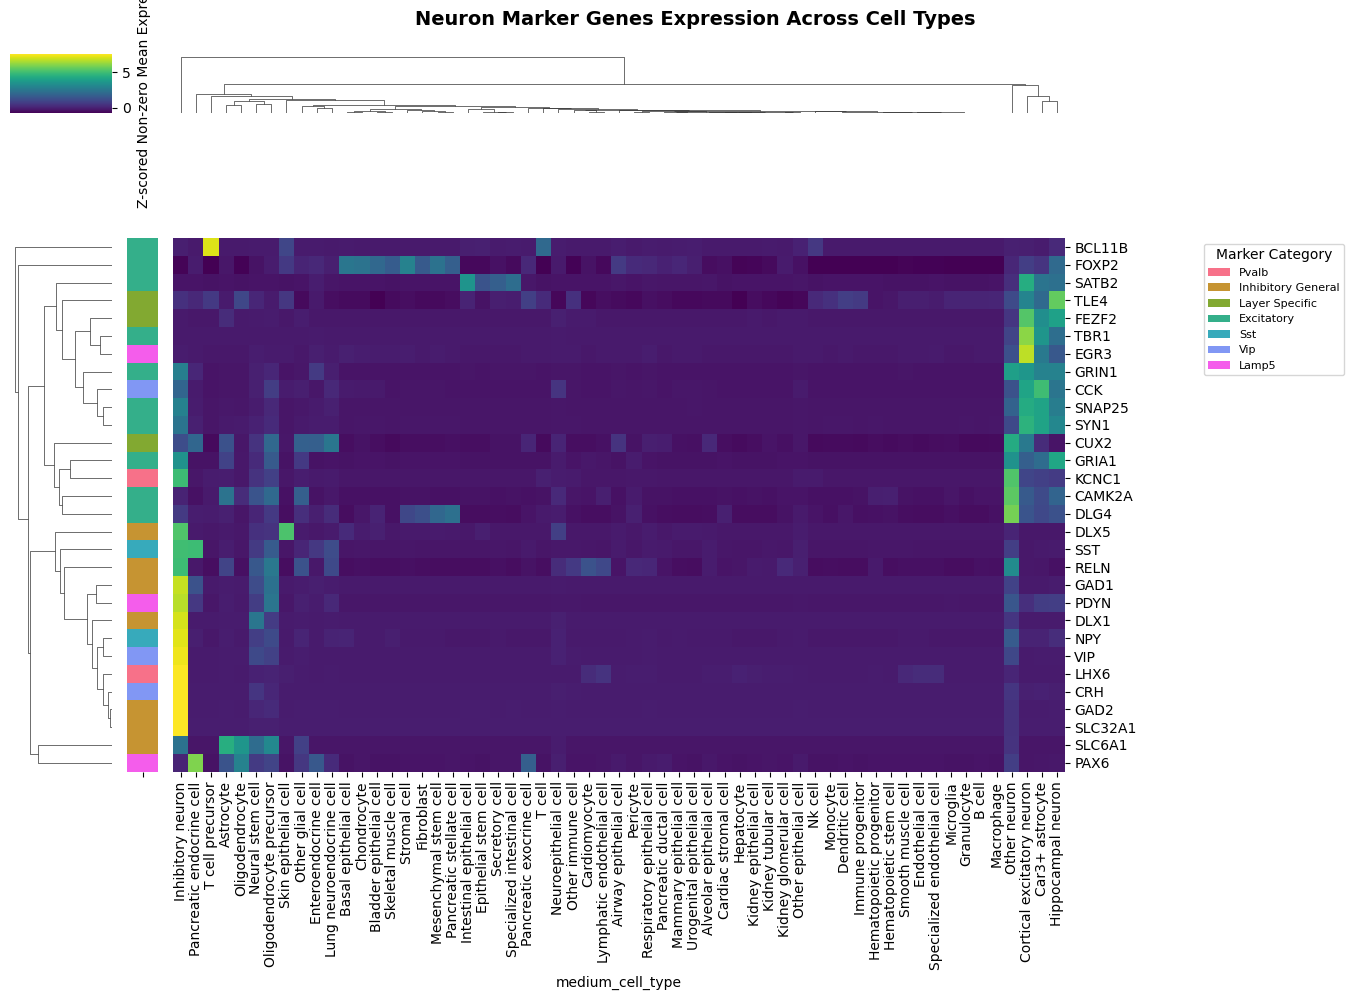


Processing: Immune cell
  Found 25/62 markers for Immune cell


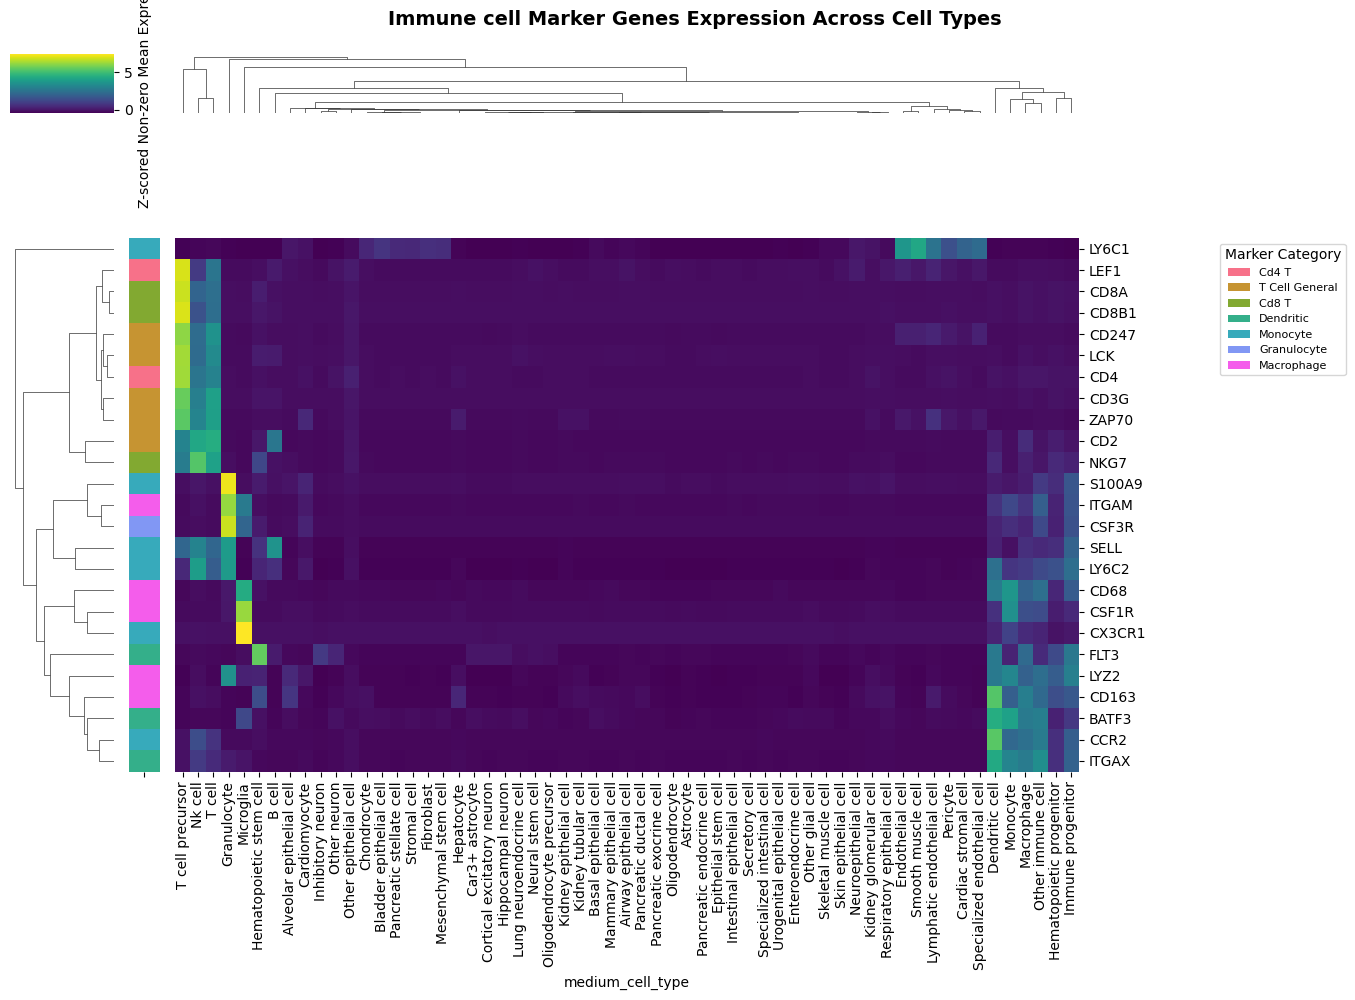


Processing: Glial cell
  Found 22/29 markers for Glial cell


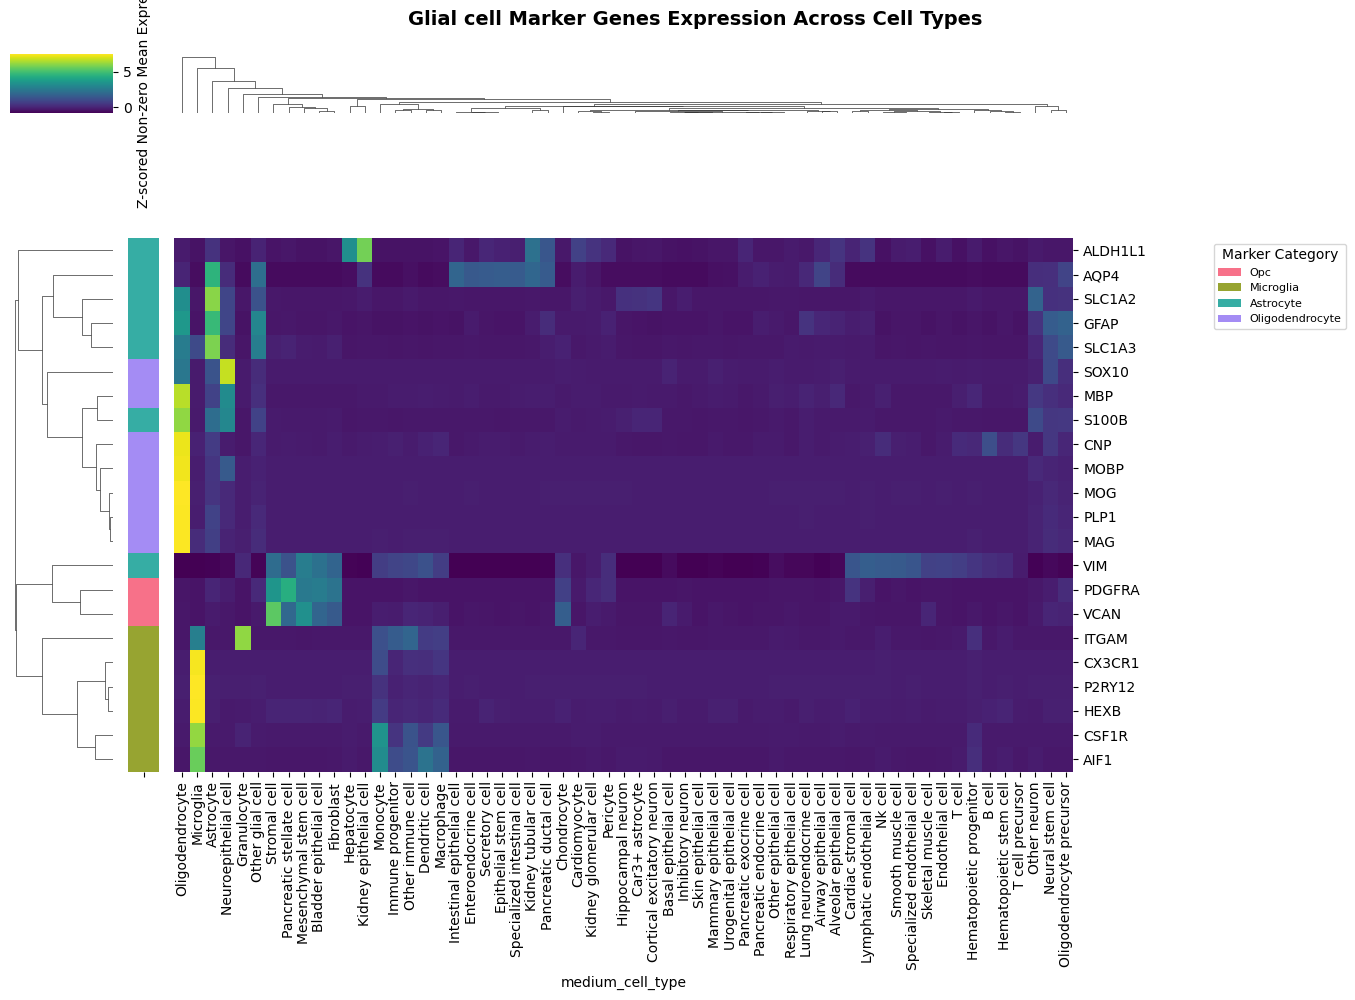


Processing: Epithelial cell
  Found 14/32 markers for Epithelial cell


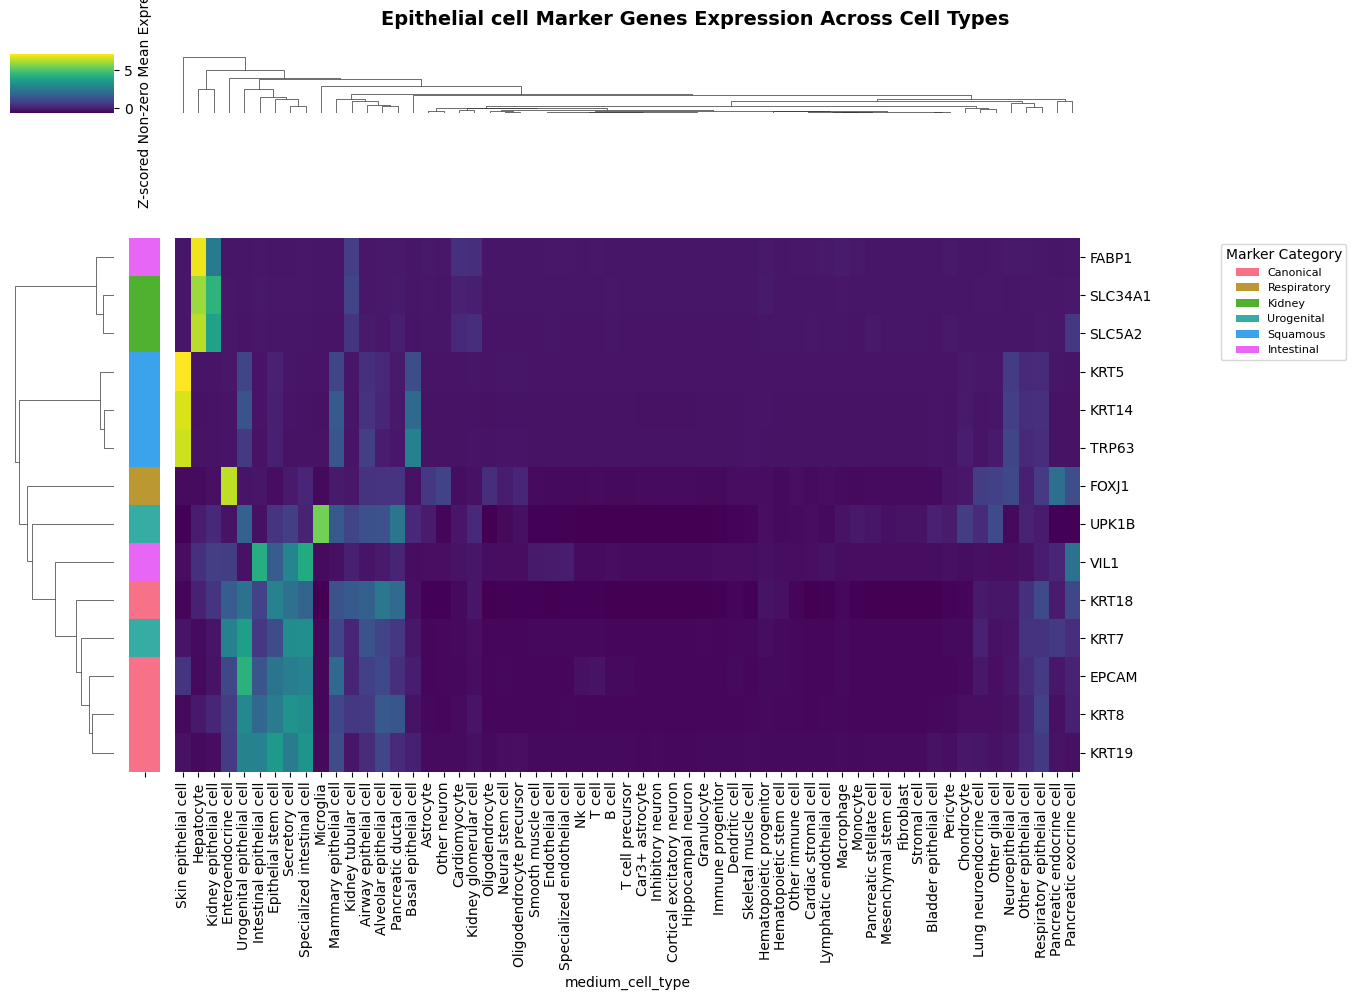


Processing: Stem cell
  Found 16/22 markers for Stem cell


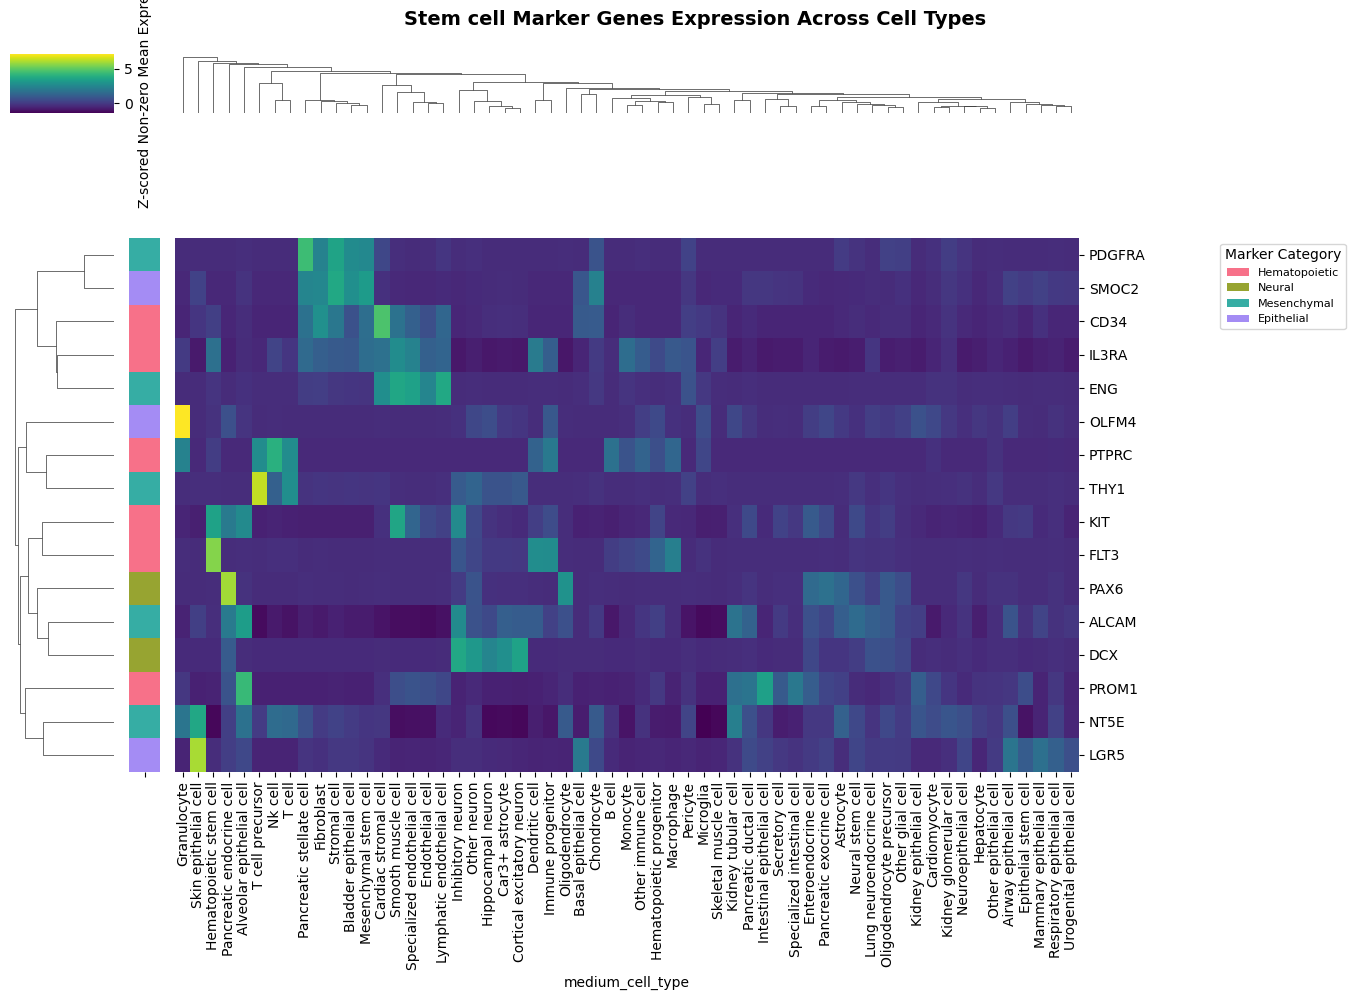


Processing: Vascular cell
  Found 21/30 markers for Vascular cell


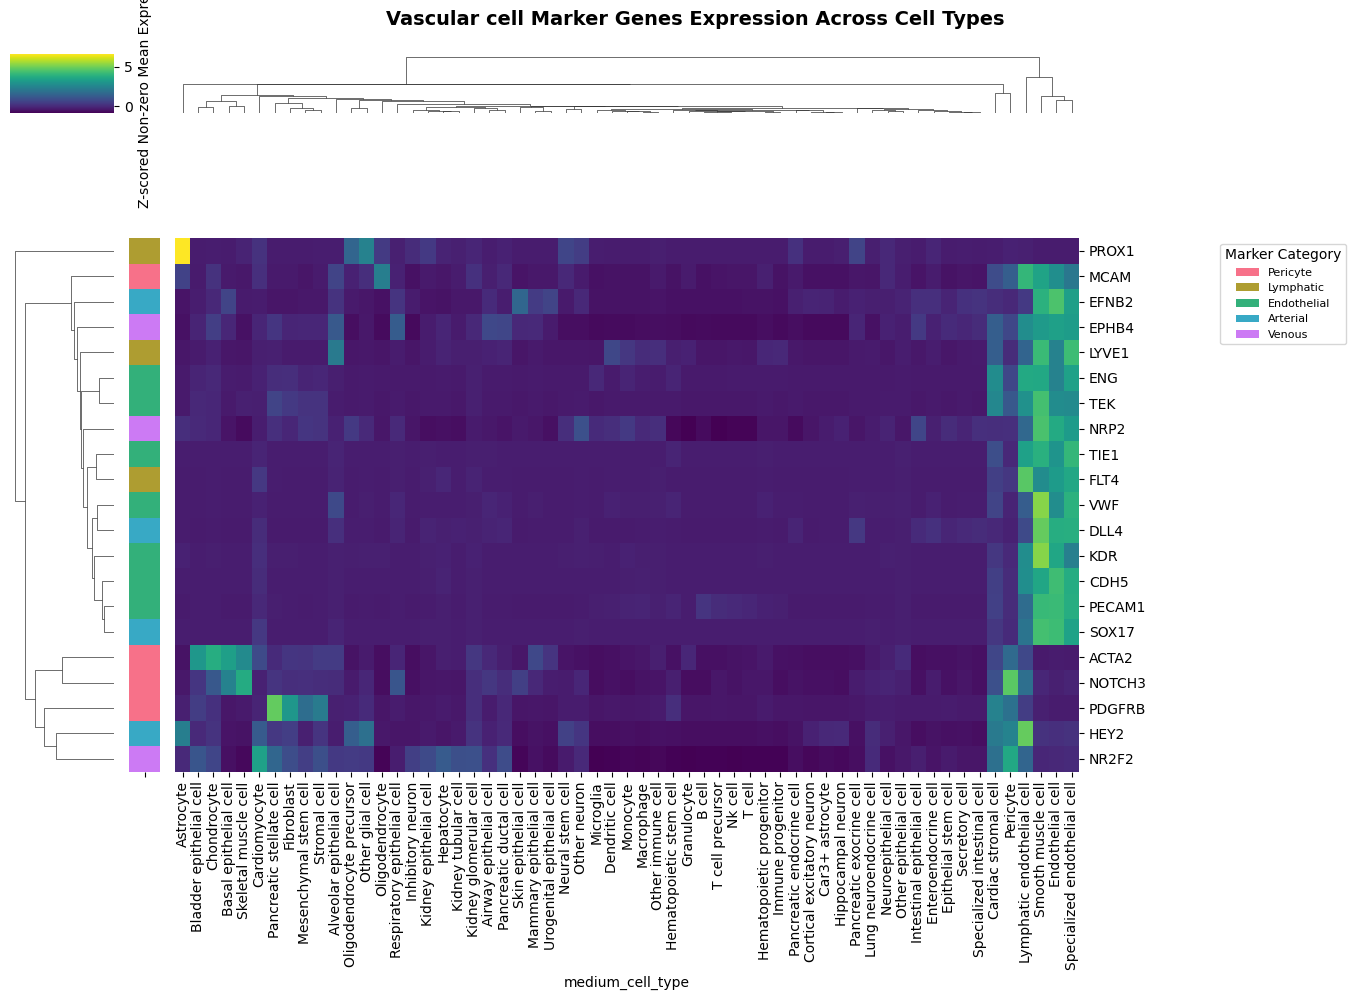


Processing: Stromal cell
  Found 17/20 markers for Stromal cell


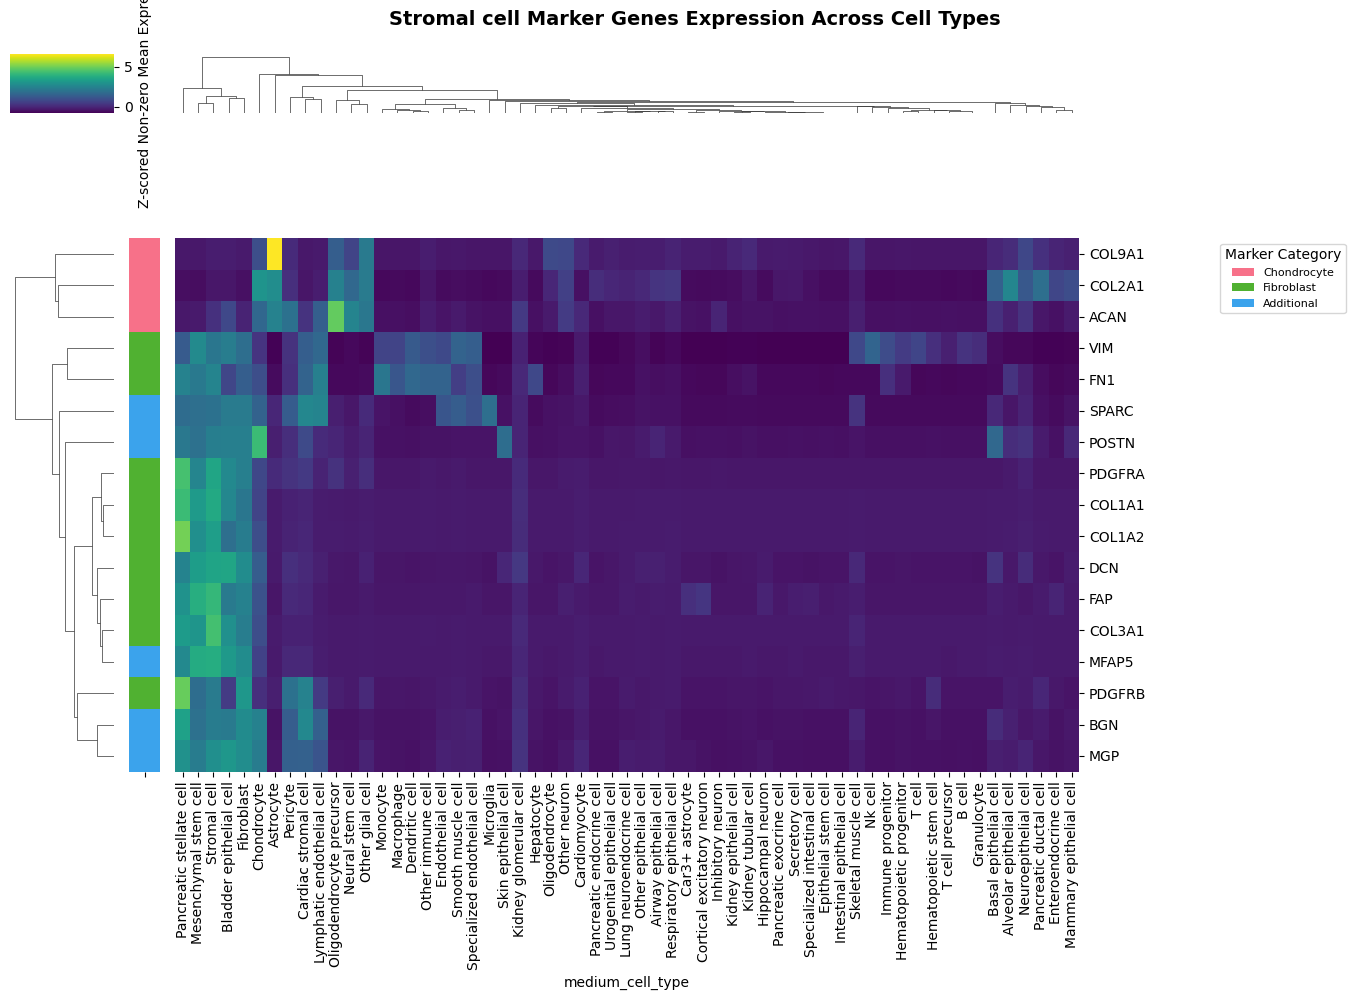


Processing: Muscle cell
  Found 13/20 markers for Muscle cell


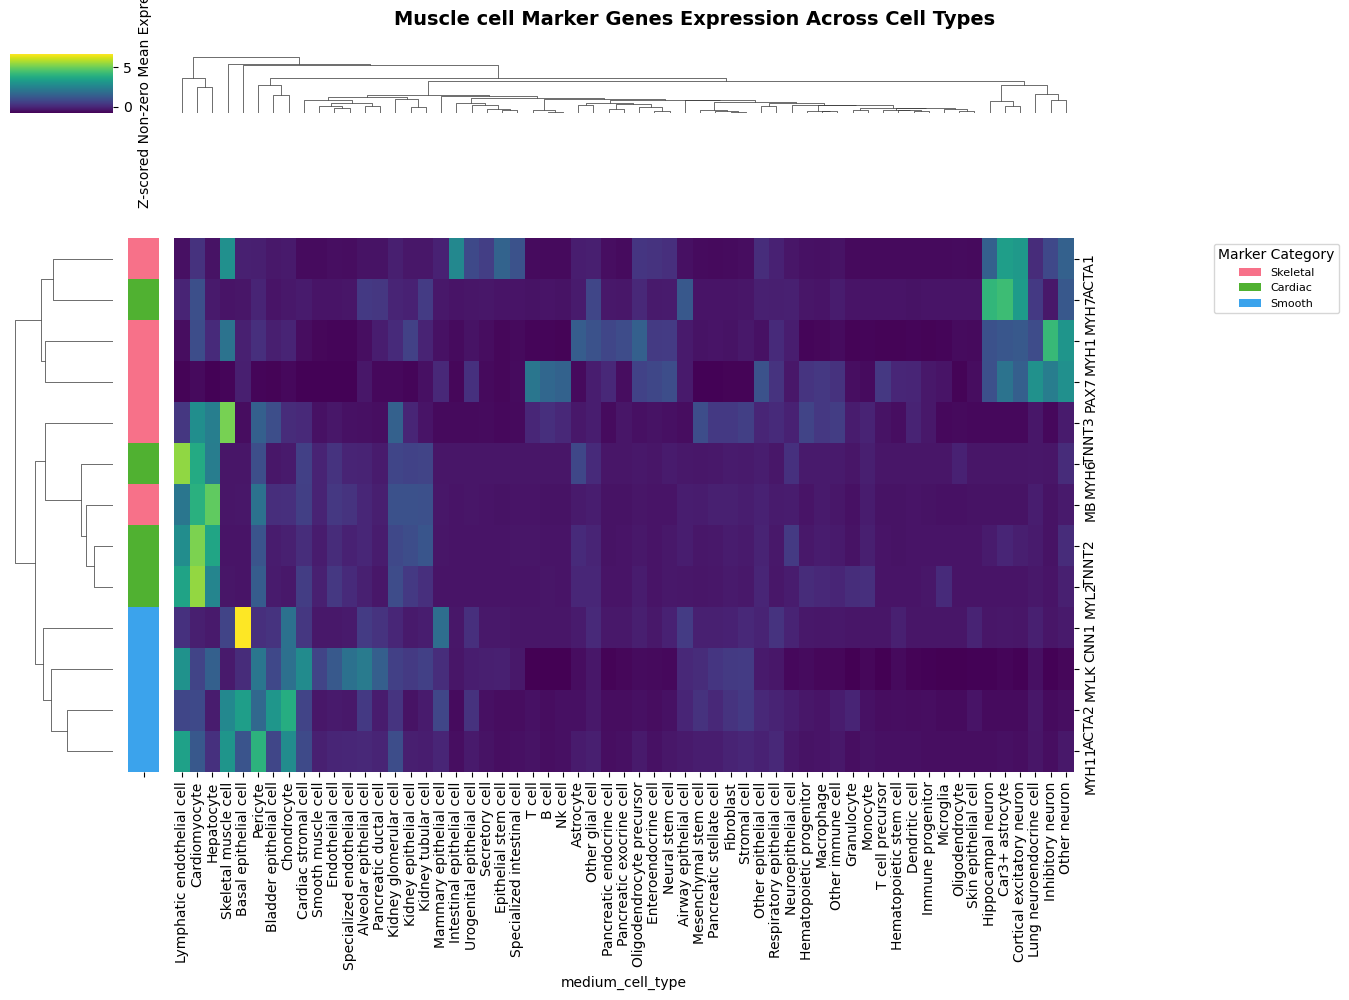


Processing: Pancreatic cell
  Found 15/26 markers for Pancreatic cell


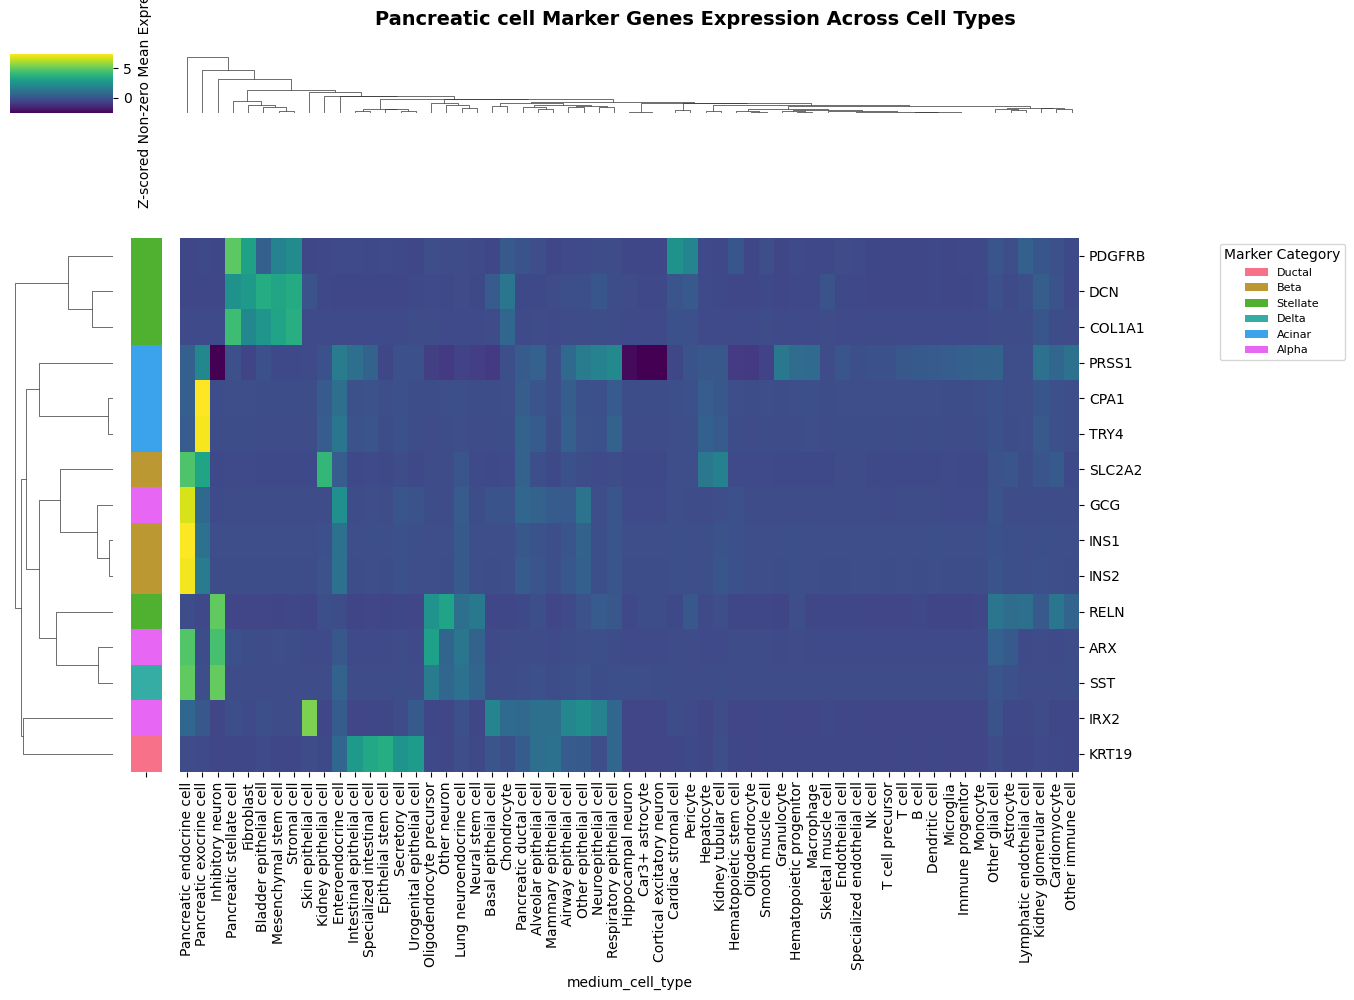


Processing: Intestinal cell
  Found 8/19 markers for Intestinal cell


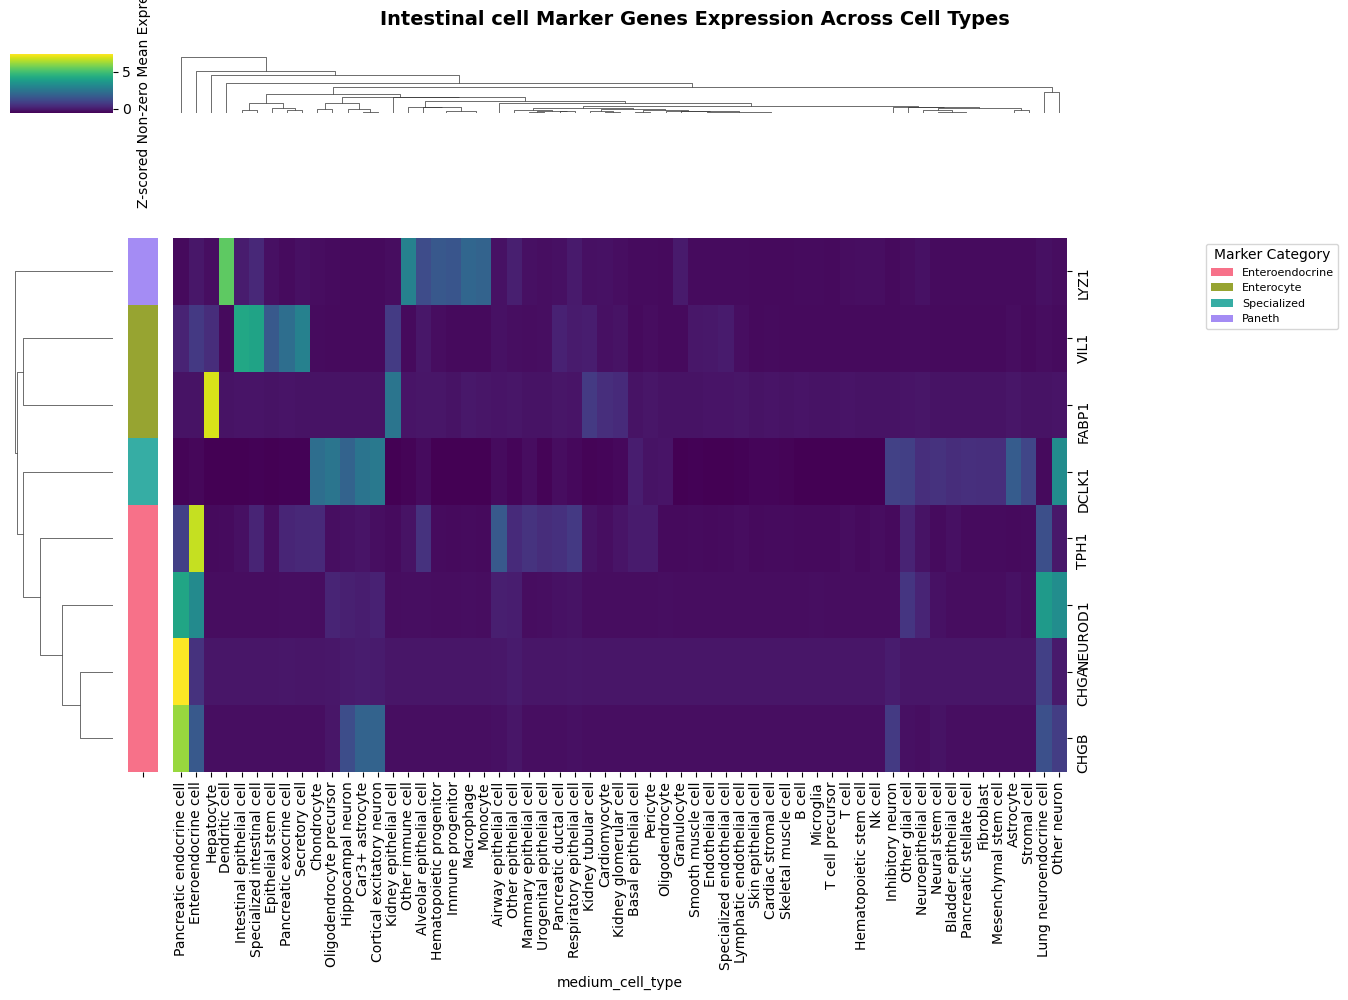

In [27]:
# Convert the DataFrame columns to gene names
ge_adata.obsm["X_normalized_scVI_linear"].columns = ge_adata.var_names

# Or if you prefer to use a specific column from var
ge_adata.obsm["X_normalized_scVI_linear"].columns = ge_adata.var["gene_name"].values

# Verify the change
print("First 10 column names:")
print(ge_adata.obsm["X_normalized_scVI_linear"].columns[:10].tolist())

print("\nLast 10 column names:")
print(ge_adata.obsm["X_normalized_scVI_linear"].columns[-10:].tolist())

# Usage example:
# Get marker availability summary
marker_summary = get_marker_expression_summary(ge_adata)
print("\nMarker Gene Availability Summary:")
print(marker_summary[['total_markers', 'available_markers', 'percentage']])

# Create heatmaps for top 5 most abundant cell types
top_cell_types = ge_adata.obs['broad_cell_type'].value_counts().head(10).index.tolist()

create_all_cell_type_heatmaps(
    ge_adata,
    cell_types=top_cell_types,
    save_dir='/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/GeneExpression/marker_gene_plots/'  # Optional: specify directory to save
)

In [28]:
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index
print(f"The number of cells in the dataset is {splice_adata.shape[0]}", flush=True)

The number of cells in the dataset is 142315


In [29]:
# Fix sex labels in splice_adata
splice_adata.obs['sex'] = splice_adata.obs['sex'].replace({
    'male': 'M',
    'female': 'F'
})

# Verify
print("splice_adata sex counts:")
print(splice_adata.obs["sex"].value_counts())

# Fix sex labels in ge_adata
ge_adata.obs['sex'] = ge_adata.obs['sex'].replace({
    'male': 'M',
    'female': 'F'
})

# Verify
print("\nge_adata sex counts:")
print(ge_adata.obs["sex"].value_counts())

splice_adata sex counts:
sex
M    87943
F    54372
Name: count, dtype: int64

ge_adata sex counts:
sex
M    87943
F    54372
Name: count, dtype: int64


In [31]:
ge_adata.obs_names

Index(['A10_B000120', 'A10_B000126', 'A10_B000127', 'A10_B000166',
       'A10_B000169', 'A10_B000170', 'A10_B000176', 'A10_B000229',
       'A10_B000232', 'A10_B000246',
       ...
       'US-1250275_E2_S77', 'US-1250275_E2_S78', 'US-1250275_E2_S82',
       'US-1250275_E2_S83', 'US-1250275_E2_S85', 'US-1250275_E2_S86',
       'US-1250275_E2_S87', 'US-1250275_E2_S88', 'US-1250275_E2_S89',
       'US-1250275_E2_S90'],
      dtype='object', name='cell_id', length=142315)

In [33]:
splice_adata.obs_names = splice_adata.obs["cell_id"]

In [34]:
# assert that splice_adata.obs and ge_adata.obs are the same 
# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values) 

In [35]:
# Convert gene names to string type
splice_adata.var["gene_name"] = splice_adata.var["gene_name"].astype(str)
ge_adata.var["gene_name"] = ge_adata.var["gene_name"].astype(str)

# Create sets of gene names
splice_genes_set = set(splice_adata.var["gene_name"])
ge_genes_set = set(ge_adata.var["gene_name"])

# Find common genes
common_genes = splice_genes_set & ge_genes_set
print(f"Number of genes in splice_adata: {len(splice_genes_set)}")
print(f"Number of genes in ge_adata: {len(ge_genes_set)}")
print(f"Number of common genes: {len(common_genes)}")

# Subset both AnnData objects to only common genes
# Create boolean masks for rows where gene_name is in common_genes
splice_mask = splice_adata.var["gene_name"].isin(common_genes)
ge_mask = ge_adata.var["gene_name"].isin(common_genes)

# Subset the AnnData objects
splice_adata = splice_adata[:, splice_mask].copy()
ge_adata = ge_adata[:, ge_mask].copy()

print(f"\nAfter subsetting:")
print(f"splice_adata shape: {splice_adata.shape}")
print(f"ge_adata shape: {ge_adata.shape}")

# Verify they now have the same genes
print(f"\nVerification:")
print(f"Number of genes in splice_adata: {splice_adata.n_vars}")
print(f"Number of genes in ge_adata: {ge_adata.n_vars}")

Number of genes in splice_adata: 10572
Number of genes in ge_adata: 10572
Number of common genes: 10572

After subsetting:
splice_adata shape: (142315, 89831)
ge_adata shape: (142315, 10572)

Verification:
Number of genes in splice_adata: 89831
Number of genes in ge_adata: 10572


In [36]:
splice_adata.var["junction_id_index"] = range(splice_adata.var.shape[0])
splice_adata.var.reset_index(inplace=True)

In [37]:
print(f"Final number of genes in both datasets: {splice_adata.var['gene_name'].nunique()}")
print(f"Final number of ATSEs in both datasets: {splice_adata.var['event_id'].nunique()}")
print(f"Final number of Junctions in both datasets: {splice_adata.var['junction_id'].nunique()}")

Final number of genes in both datasets: 10572
Final number of ATSEs in both datasets: 28015
Final number of Junctions in both datasets: 89831


In [38]:
# Save final versions of the files 
import os
from datetime import datetime

# Set new model date and shared output directory
new_model_date = "102025"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
GE_OUTPUT_DIR = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/{new_model_date}"
os.makedirs(GE_OUTPUT_DIR, exist_ok=True)

# ---- Gene Expression ----
ge_new_filename = f"model_ready_gene_expression_data_{timestamp}.h5ad"
GE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, ge_new_filename)

# Save filtered gene expression data
ge_adata.write(GE_OUTPUT_PATH, compression="lzf")
print(f"Filtered gene expression AnnData written to:\n{GE_OUTPUT_PATH}")

# ---- Splicing Data ----
splice_new_filename = f"model_ready_aligned_splicing_data_{timestamp}.h5ad"
SPLICE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, splice_new_filename)
# Subset and save matched splicing data
splice_adata.write(SPLICE_OUTPUT_PATH, compression="lzf")
print(f"Filtered splicing AnnData written to:\n{SPLICE_OUTPUT_PATH}")

Filtered gene expression AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/102025/model_ready_gene_expression_data_20251009_024406.h5ad
Filtered splicing AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/102025/model_ready_aligned_splicing_data_20251009_024406.h5ad


In [40]:
splice_adata.obs

,cell_id_index,age,cell_ontology_class,mouse.id,sex,subtissue,tissue,dataset,cell_name,cell_id,...,specific_cell_type,broad_cell_type,medium_cell_type,seqtech,library_size,total_junction_reads,annotated_junction_reads,unannotated_junction_reads,n_detected_annotated_junctions,n_detected_unannotated_junctions
cell_id,,,,,,,,,,,,,,,,,,,,,
A10_B000120,0,18m,basal epithelial cell of tracheobronchial tree,18_47_F,F,NaN,Trachea,TMS,A10_B000120,A10_B000120,...,Tracheobronchial basal epithelial cell,Epithelial cell,Respiratory epithelial cell,single_cell,6797,6061,5897,164,406,16
A10_B000126,1,3m,bulge keratinocyte,3_39_F,F,Telogen,Skin,TMS,A10_B000126,A10_B000126,...,Bulge keratinocyte,Epithelial cell,Skin epithelial cell,single_cell,33982,30890,30304,586,1661,46
A10_B000127,2,3m,myeloid cell,3_38_F,F,Fat,SCAT,TMS,A10_B000127,A10_B000127,...,Myeloid cell,Immune cell,Other immune cell,single_cell,17044,15105,14744,361,363,31
A10_B000166,3,3m,basal cell,3_56_F,F,Mammary_Gland,Mammary_Gland,TMS,A10_B000166,A10_B000166,...,Basal cell,Epithelial cell,Basal epithelial cell,single_cell,279337,254958,249373,5585,4246,164
A10_B000169,4,18m,endothelial cell of coronary artery,18_53_M,M,RV,Heart,TMS,A10_B000169,A10_B000169,...,Coronary endothelial cell,Vascular cell,Endothelial cell,single_cell,17794,15666,15545,121,350,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US-1250275_E2_S86,142310,2m,197_L5 IT CTX,184750,F,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S86,US-1250275_E2_S86,...,Layer 5 excitatory neuron,Neuron,Cortical excitatory neuron,single_nuclei,53587,48275,45749,2526,9393,240
US-1250275_E2_S87,142311,2m,204_L5/6 IT CTX,184756,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S87,US-1250275_E2_S87,...,Layer 5 excitatory neuron,Neuron,Cortical excitatory neuron,single_nuclei,44150,39687,36238,3449,8268,218
US-1250275_E2_S88,142312,2m,257_L5 PT CTX,185199,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S88,US-1250275_E2_S88,...,Layer 5 excitatory neuron,Neuron,Cortical excitatory neuron,single_nuclei,48161,42726,39975,2751,10177,232


In [41]:
splice_adata.var

,index,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,aging_gene,aging_lifespan_effect,aging_longevity_influence
0,0,chr10_100016035_100051845_+,ENSMUSG00000019966.18_atse_1,GT-AG,both,KITL,ENSMUSG00000019966.18,2,0.0,1.0,206861,0,10741,high,False,NaN,NaN
1,1,chr10_100016155_100051845_+,ENSMUSG00000019966.18_atse_1,GT-AG,both,KITL,ENSMUSG00000019966.18,2,0.0,1.0,5002,1,795,high,False,NaN,NaN
2,2,chr10_100080130_100080856_+,ENSMUSG00000019966.18_atse_2,GT-AG,both,KITL,ENSMUSG00000019966.18,3,0.0,1.0,198469,2,10198,high,False,NaN,NaN
3,3,chr10_100080130_100087346_+,ENSMUSG00000019966.18_atse_2,GT-AG,both,KITL,ENSMUSG00000019966.18,3,0.0,1.0,108170,3,2156,high,False,NaN,NaN
4,4,chr10_100080940_100087346_+,ENSMUSG00000019966.18_atse_2,GT-AG,both,KITL,ENSMUSG00000019966.18,3,0.0,1.0,180342,4,9991,high,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89826,113990,chrY_928384_936875_+,ENSMUSG00000056673.14_atse_7,GT-AG,both,KDM5D,ENSMUSG00000056673.14,2,0.0,1.0,12512,89826,2133,high,False,NaN,NaN
89827,113991,chrY_938171_939818_+,ENSMUSG00000056673.14_atse_8,GT-AG,both,KDM5D,ENSMUSG00000056673.14,2,0.0,1.0,9855,89827,2119,high,False,NaN,NaN
89828,113992,chrY_938171_940023_+,ENSMUSG00000056673.14_atse_8,GT-AG,five_prime,KDM5D,ENSMUSG00000056673.14,2,0.0,NaN,164,89828,38,low,False,NaN,NaN
89829,113993,chrY_939957_940598_+,ENSMUSG00000056673.14_atse_9,GT-AG,both,KDM5D,ENSMUSG00000056673.14,2,0.0,1.0,13870,89829,2378,high,False,NaN,NaN
